# Model B - Seasonal Naive (Horizon 2 Triwulan)
Notebook ini melatih baseline seasonal naive untuk memprediksi jumlah gempa M>=5 dua triwulan ke depan,
dengan feature engineering tambahan yang disimpan sebagai artifacts untuk eksperimen lanjutan.

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

In [ ]:
# Konfigurasi eksperimen Model B
DATA_PATH = Path('data_gempa_kaggle/katalog_gempa_v2.tsv')
ARTIFACT_DIR = Path('artifacts/model_b_h2')
TARGET_COL = 'count_m5'
MAG_THRESHOLD = 5.0
HORIZON = 2
SEASON_LENGTH = 4
TEST_QUARTERS = 8

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print('Artifact dir:', ARTIFACT_DIR.resolve())

Artifact dir: D:\Projects\bencana_dicoding_app\timeseries_triwulan\notebooks\timeseries_triwulan\artifacts\model_b_h2


In [3]:
# Load dan pembersihan awal data
df = pd.read_csv(DATA_PATH, sep='\t', low_memory=False)
df['datetime'] = pd.to_datetime(df['datetime'], utc=True, errors='coerce')
df = df.dropna(subset=['datetime', 'magnitude']).copy()
df['datetime'] = df['datetime'].dt.tz_convert(None)

print('Rows after cleaning:', len(df))
print('Min datetime:', df['datetime'].min())
print('Max datetime:', df['datetime'].max())

Rows after cleaning: 131131
Min datetime: 2008-11-01 00:31:25.143741
Max datetime: 2025-10-01 12:30:19.302639


In [4]:
# Agregasi triwulan + drop triwulan parsial terakhir jika belum lengkap
q_all = df.resample('QE', on='datetime').size().rename('count_all')
q_m5 = (df[df['magnitude'] >= MAG_THRESHOLD]\
        .resample('QE', on='datetime').size().rename('count_m5'))
quarterly = pd.concat([q_all, q_m5], axis=1).fillna(0.0)
quarterly.index.name = 'quarter_end'

last_ts = df['datetime'].max()
last_q_end = last_ts.to_period('Q').end_time
dropped_partial_quarter = False
if last_ts < last_q_end and len(quarterly) > 0:
    quarterly = quarterly.iloc[:-1].copy()
    dropped_partial_quarter = True

quarterly['quarter'] = quarterly.index.to_period('Q').astype(str)
quarterly = quarterly.reset_index(drop=False)

print('Total quarter rows:', len(quarterly))
print('Dropped partial last quarter:', dropped_partial_quarter)
quarterly.tail()

Total quarter rows: 68
Dropped partial last quarter: True


,quarter_end,count_all,count_m5,quarter
63,2024-09-30,1571,39.0,2024Q3
64,2024-12-31,1655,25.0,2024Q4
65,2025-03-31,3876,27.0,2025Q1
66,2025-06-30,4820,13.0,2025Q2
67,2025-09-30,5084,25.0,2025Q3


In [5]:
# Feature engineering yang cocok untuk time series triwulan
feat_df = quarterly.copy()
for lag in [1, 2, 4, 8]:
    feat_df[f'lag_{lag}'] = feat_df[TARGET_COL].shift(lag)

for w in [2, 4, 8]:
    feat_df[f'roll_mean_{w}'] = feat_df[TARGET_COL].shift(1).rolling(w).mean()
    feat_df[f'roll_std_{w}'] = feat_df[TARGET_COL].shift(1).rolling(w).std()

feat_df['yoy_diff_4'] = feat_df[TARGET_COL] - feat_df[TARGET_COL].shift(4)
feat_df['yoy_ratio_4'] = feat_df[TARGET_COL] / feat_df[TARGET_COL].shift(4).replace(0, np.nan)

feat_df.to_csv(ARTIFACT_DIR / 'feature_table.csv', index=False)
feat_df.tail()

,quarter_end,count_all,count_m5,quarter,lag_1,lag_2,lag_4,lag_8,roll_mean_2,roll_std_2,roll_mean_4,roll_std_4,roll_mean_8,roll_std_8,yoy_diff_4,yoy_ratio_4
63,2024-09-30,1571,39.0,2024Q3,31.0,46.0,63.0,50.0,38.5,10.606602,52.00,16.872068,51.250,11.209052,-24.0,0.619048
64,2024-12-31,1655,25.0,2024Q4,39.0,31.0,68.0,47.0,35.0,5.656854,46.00,15.895492,49.875,12.028983,-43.0,0.367647
65,2025-03-31,3876,27.0,2025Q1,25.0,39.0,46.0,52.0,32.0,9.899495,35.25,9.178780,47.125,14.942150,-19.0,0.586957
66,2025-06-30,4820,13.0,2025Q2,27.0,25.0,31.0,53.0,26.0,1.414214,30.50,6.191392,44.000,16.327015,-18.0,0.419355
67,2025-09-30,5084,25.0,2025Q3,13.0,27.0,39.0,63.0,20.0,9.899495,26.00,10.645813,39.000,19.071295,-14.0,0.641026


In [6]:
# Split data berbasis waktu
n = len(quarterly)
if n <= TEST_QUARTERS + SEASON_LENGTH + HORIZON:
    raise ValueError('Data triwulan terlalu sedikit untuk split yang aman.')

train_end = n - TEST_QUARTERS
train_df = quarterly.iloc[:train_end].copy()
test_df = quarterly.iloc[train_end:].copy()

train_df.to_csv(ARTIFACT_DIR / 'train_split.csv', index=False)
test_df.to_csv(ARTIFACT_DIR / 'test_split.csv', index=False)

print('Train rows:', len(train_df))
print('Test rows :', len(test_df))
print('Train quarter range:', train_df['quarter'].iloc[0], '->', train_df['quarter'].iloc[-1])
print('Test quarter range :', test_df['quarter'].iloc[0], '->', test_df['quarter'].iloc[-1])

Train rows: 60
Test rows : 8
Train quarter range: 2008Q4 -> 2023Q3
Test quarter range : 2023Q4 -> 2025Q3


In [7]:
# Seasonal naive direct forecasting untuk horizon HORIZON
series = quarterly[TARGET_COL].astype(float).reset_index(drop=True)
pred_rows = []

for origin_idx in range(train_end - 1, n - HORIZON):
    target_idx = origin_idx + HORIZON
    seasonal_idx = target_idx - SEASON_LENGTH

    if origin_idx < 0:
        continue
    if seasonal_idx < 0:
        continue

    y_true = float(series.iloc[target_idx])
    y_pred = float(series.iloc[seasonal_idx])

    pred_rows.append({
        'target_idx': int(target_idx),
        'origin_idx': int(origin_idx),
        'quarter': quarterly.loc[target_idx, 'quarter'],
        'actual': y_true,
        'pred': y_pred,
        'abs_error': abs(y_true - y_pred),
        'sq_error': (y_true - y_pred) ** 2
    })

pred_df = pd.DataFrame(pred_rows)
if pred_df.empty:
    raise ValueError('Prediksi kosong. Cek konfigurasi split/horizon/season length.')

mae = float(pred_df['abs_error'].mean())
rmse = float(np.sqrt(pred_df['sq_error'].mean()))
den = (pred_df['actual'].abs() + pred_df['pred'].abs()).replace(0, np.nan)
smape = float((2.0 * (pred_df['actual'] - pred_df['pred']).abs() / den).dropna().mean() * 100.0)

pred_df.to_csv(ARTIFACT_DIR / 'forecast_test.csv', index=False)
print('MAE :', round(mae, 4))
print('RMSE:', round(rmse, 4))
print('sMAPE(%):', round(smape, 4))
pred_df

MAE : 20.8571
RMSE: 23.3789
sMAPE(%): 54.5401


,target_idx,origin_idx,quarter,actual,pred,abs_error,sq_error
0,61,59,2024Q1,46.0,52.0,6.0,36.0
1,62,60,2024Q2,31.0,53.0,22.0,484.0
2,63,61,2024Q3,39.0,63.0,24.0,576.0
3,64,62,2024Q4,25.0,68.0,43.0,1849.0
4,65,63,2025Q1,27.0,46.0,19.0,361.0
5,66,64,2025Q2,13.0,31.0,18.0,324.0
6,67,65,2025Q3,25.0,39.0,14.0,196.0


In [8]:
# Simpan model artifact (konfigurasi model seasonal naive) + metadata eksperimen
model_artifact = {
    'model_name': 'seasonal_naive',
    'horizon_quarter': HORIZON,
    'season_length_quarter': SEASON_LENGTH,
    'target_col': TARGET_COL,
    'mag_threshold': MAG_THRESHOLD,
    'train_end_index': int(train_end),
    'test_quarters': int(TEST_QUARTERS)
}
joblib.dump(model_artifact, ARTIFACT_DIR / 'model.joblib')

metadata = {
    'dataset_path': str(DATA_PATH),
    'total_events_after_cleaning': int(len(df)),
    'quarter_rows_after_cleaning': int(len(quarterly)),
    'dropped_partial_last_quarter': bool(dropped_partial_quarter),
    'target_col': TARGET_COL,
    'horizon_quarter': int(HORIZON),
    'season_length_quarter': int(SEASON_LENGTH),
    'test_quarters': int(TEST_QUARTERS),
    'train_rows': int(len(train_df)),
    'test_rows': int(len(test_df)),
    'metrics': {
        'mae': mae,
        'rmse': rmse,
        'smape_percent': smape
    }
}

with open(ARTIFACT_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print('Saved files:')
for p in sorted(ARTIFACT_DIR.glob('*')):
    print('-', p.name)

Saved files:
- feature_table.csv
- forecast_test.csv
- metadata.json
- model.joblib
- test_split.csv
- train_split.csv


## Visualisasi Hasil Test
Bagian ini menampilkan perbandingan aktual vs prediksi pada data test, distribusi error per triwulan, dan ringkasan metrik evaluasi.

Ringkasan metrik evaluasi:


,metric,value
0,MAE,20.857143
1,RMSE,23.378867
2,sMAPE(%),54.540110


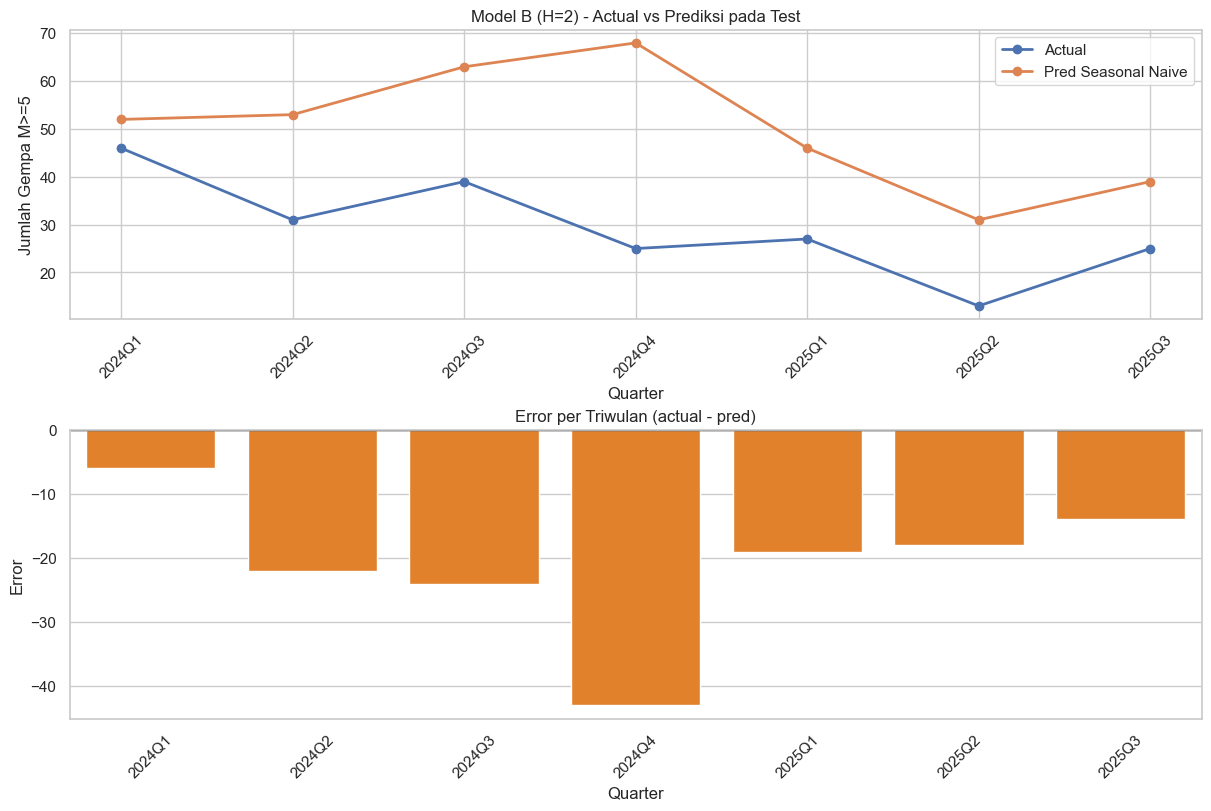

,quarter,actual,pred,error,abs_error
0,2024Q1,46.0,52.0,-6.0,6.0
1,2024Q2,31.0,53.0,-22.0,22.0
2,2024Q3,39.0,63.0,-24.0,24.0
3,2024Q4,25.0,68.0,-43.0,43.0
4,2025Q1,27.0,46.0,-19.0,19.0
5,2025Q2,13.0,31.0,-18.0,18.0
6,2025Q3,25.0,39.0,-14.0,14.0


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

viz_df = pred_df.copy()
viz_df = viz_df.sort_values('quarter').reset_index(drop=True)
viz_df['error'] = viz_df['actual'] - viz_df['pred']

metrics_table = pd.DataFrame([
    {'metric': 'MAE', 'value': mae},
    {'metric': 'RMSE', 'value': rmse},
    {'metric': 'sMAPE(%)', 'value': smape},
])

print('Ringkasan metrik evaluasi:')
display(metrics_table)

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

axes[0].plot(viz_df['quarter'], viz_df['actual'], marker='o', label='Actual', linewidth=2)
axes[0].plot(viz_df['quarter'], viz_df['pred'], marker='o', label='Pred Seasonal Naive', linewidth=2)
axes[0].set_title('Model B (H=2) - Actual vs Prediksi pada Test')
axes[0].set_xlabel('Quarter')
axes[0].set_ylabel('Jumlah Gempa M>=5')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

sns.barplot(data=viz_df, x='quarter', y='error', color='#ff7f0e', ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Error per Triwulan (actual - pred)')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Error')
axes[1].tick_params(axis='x', rotation=45)

plt.show()

viz_df[['quarter', 'actual', 'pred', 'error', 'abs_error']].tail(12)